# Data Visualization

In [3]:
import io
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  #For visualizing data
import plotly.express as px

In [4]:
df = pd.read_csv("data/clean/Cleaned_Sweden_Energy.csv", delimiter=",")
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_localize(None)
df = (
    df.set_index("datetime")
    .sort_index()
)
df
df.head()


,total_demand,forecast,Other,Hydro Water Reservoir,Nuclear,Wind Onshore,Solar
datetime,,,,,,,
2022-01-01 00:00:00,15331.0,14904.0,1264.88,7015.42,5842.0,4044.65,0.0
2022-01-01 01:00:00,15331.0,14760.0,1273.08,7086.16,5839.0,4021.43,0.0
2022-01-01 02:00:00,15270.0,14678.0,1277.43,7087.87,5839.0,3948.19,0.0
2022-01-01 03:00:00,15150.0,14730.0,1276.73,6745.68,5840.0,3763.19,0.0
2022-01-01 04:00:00,15387.0,14966.0,1301.19,7173.10,5839.0,3597.12,0.0


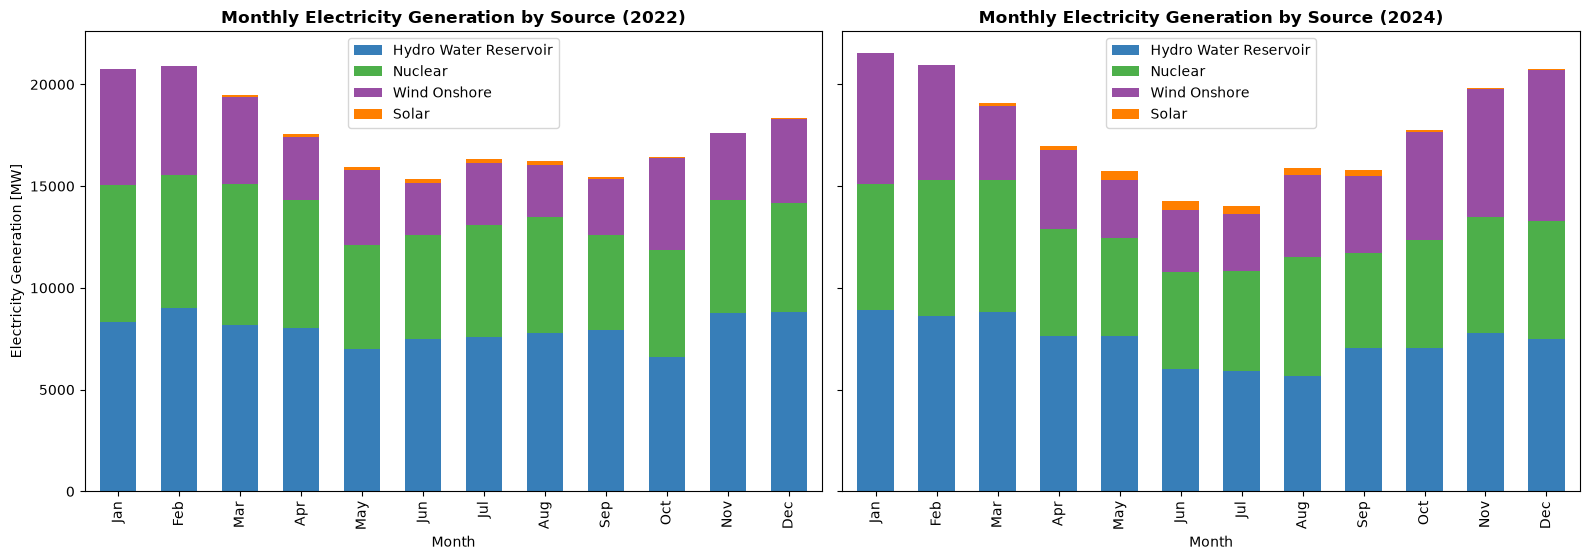

In [6]:
# Define color palette
colors = {
    'Hydro Water Reservoir': '#377eb8',
    'Nuclear': '#4daf4a',
    'Wind Onshore': '#984ea3',
    'Solar': '#ff7f00'
}

# Filter and prepare data for 2022 and 2024
df_2022_subset = df.loc['2022', ['Hydro Water Reservoir', 'Nuclear', 'Wind Onshore', 'Solar']].copy()
df_2024_subset = df.loc['2024', ['Hydro Water Reservoir', 'Nuclear', 'Wind Onshore', 'Solar']].copy()

# Resample to monthly mean
df_2022_monthly = df_2022_subset.resample('ME').mean()
df_2024_monthly = df_2024_subset.resample('ME').mean()

# Plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), sharey=True)

# 2022 plot
df_2022_monthly.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[colors[col] for col in df_2022_monthly.columns],
    width=0.6
)
axes[0].set_title('Monthly Electricity Generation by Source (2022)', fontsize=12, weight='bold')
axes[0].set_xticklabels(df_2022_monthly.index.strftime('%b'))
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Electricity Generation [MW]')
axes[0].grid(False)

# 2024 plot
df_2024_monthly.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[colors[col] for col in df_2024_monthly.columns],
    width=0.6
)
axes[1].set_title('Monthly Electricity Generation by Source (2024)', fontsize=12, weight='bold')
axes[1].set_xticklabels(df_2024_monthly.index.strftime('%b'))
axes[1].set_xlabel('Month')
axes[1].grid(False)


plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()


The stacked bar charts illustrate monthly electricity generation by source for 2022 and 2024. A notable shift in the energy mix is observed in 2024, with increases in both Wind Onshore and Solar generation, indicating a growing emphasis on renewable sources. Nuclear power provides a stable baseline, while Hydro Water Reservoir generation shows typical seasonal variations across both years

In [8]:
fig = px.line(df.total_demand)
fig.update_layout(title='Swedish Electricity Demand',xaxis_title='Time of year', yaxis_title='Swedish electricity demand [MW]')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'variable=total_demand<br>datetime=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'total_demand',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': 'total_demand',
              'showlegend': True,
              'type': 'scattergl',
              'x': array(['2022-01-01T00:00:00.000000', '2022-01-01T01:00:00.000000',
                          '2022-01-01T02:00:00.000000', ..., '2025-07-22T21:00:00.000000',
                          '2025-07-22T22:00:00.000000', '2025-07-22T23:00:00.000000'],
                         shape=(31176,), dtype='datetime64[us]'),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAIDxzUAAAAAAgPHNQAAAAAAA08' ... 'AAAADpxUAAAAAAgBfFQAAAAAAAYcRA'),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'legend': {'title': {'text': 'variable'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'title': {'text': 'Swedish Electricity Demand'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Time of year'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'Swedish electricity demand [MW]'}}}
})

Swedish electricity demand is dominated by strong seasonal patterns, with high demand in winter for heating, and low demand in summer.

The annual and intra annual demand fluctuations are consistent and predictable over the observed period (January 2022-July 2025).

There's no clear long-term growth or decline trend evident in the full years presented.

In [9]:
demand1D = np.array(df.total_demand)

number_hours = 24
number_days = int(demand1D.shape[0]/number_hours)

demand2D = demand1D.reshape(number_days, number_hours)

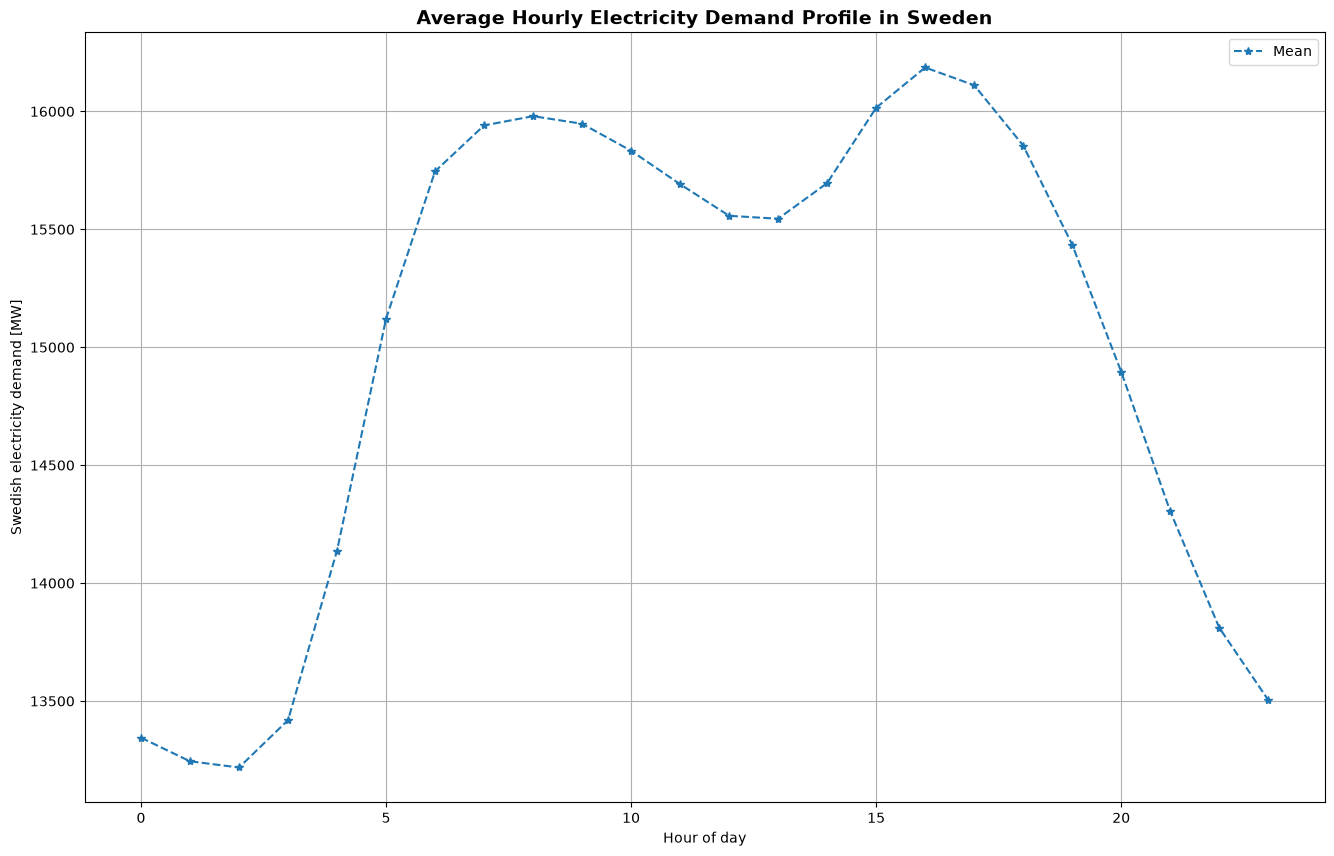

In [10]:
plt.figure(figsize=(16, 10))
plt.plot(np.nanmean(demand2D, axis=0), '*--', label="Mean")
plt.title('Average Hourly Electricity Demand Profile in Sweden', fontsize=14, fontweight='bold')
plt.xlabel('Hour of day')
plt.ylabel('Swedish electricity demand [MW]')
plt.grid(True)
plt.legend()
plt.show()

This chart reveals the average daily electricity demand profile in Sweden, showing a clear pattern driven by daily activity. Demand is lowest in the early morning at around 3 AM, rises sharply during work hours, experiences a slight mid-day dip, and peaks in the late afternoon around 4-5 PM before declining through the night. This profile reflects typical daily energy consumption habits.

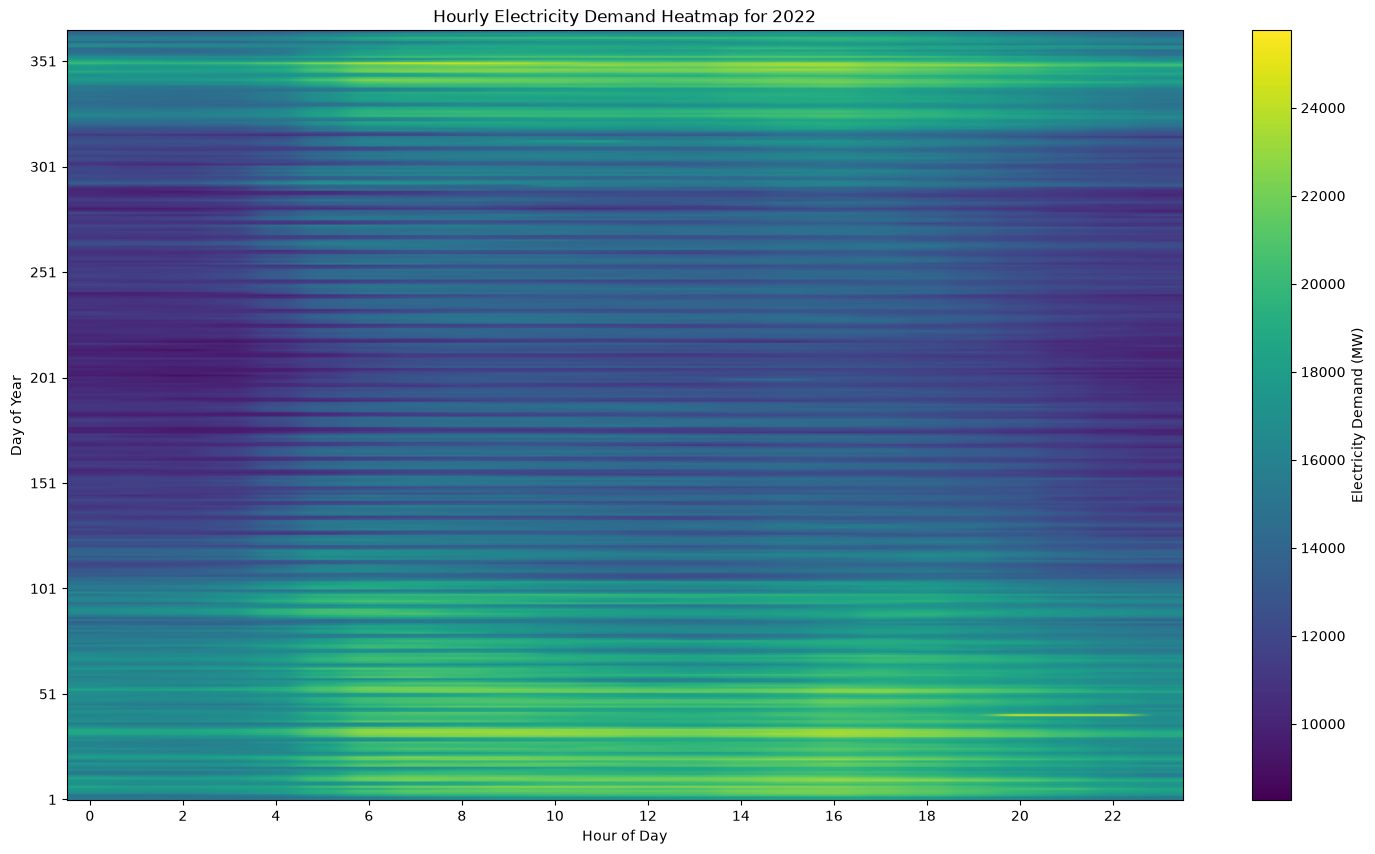

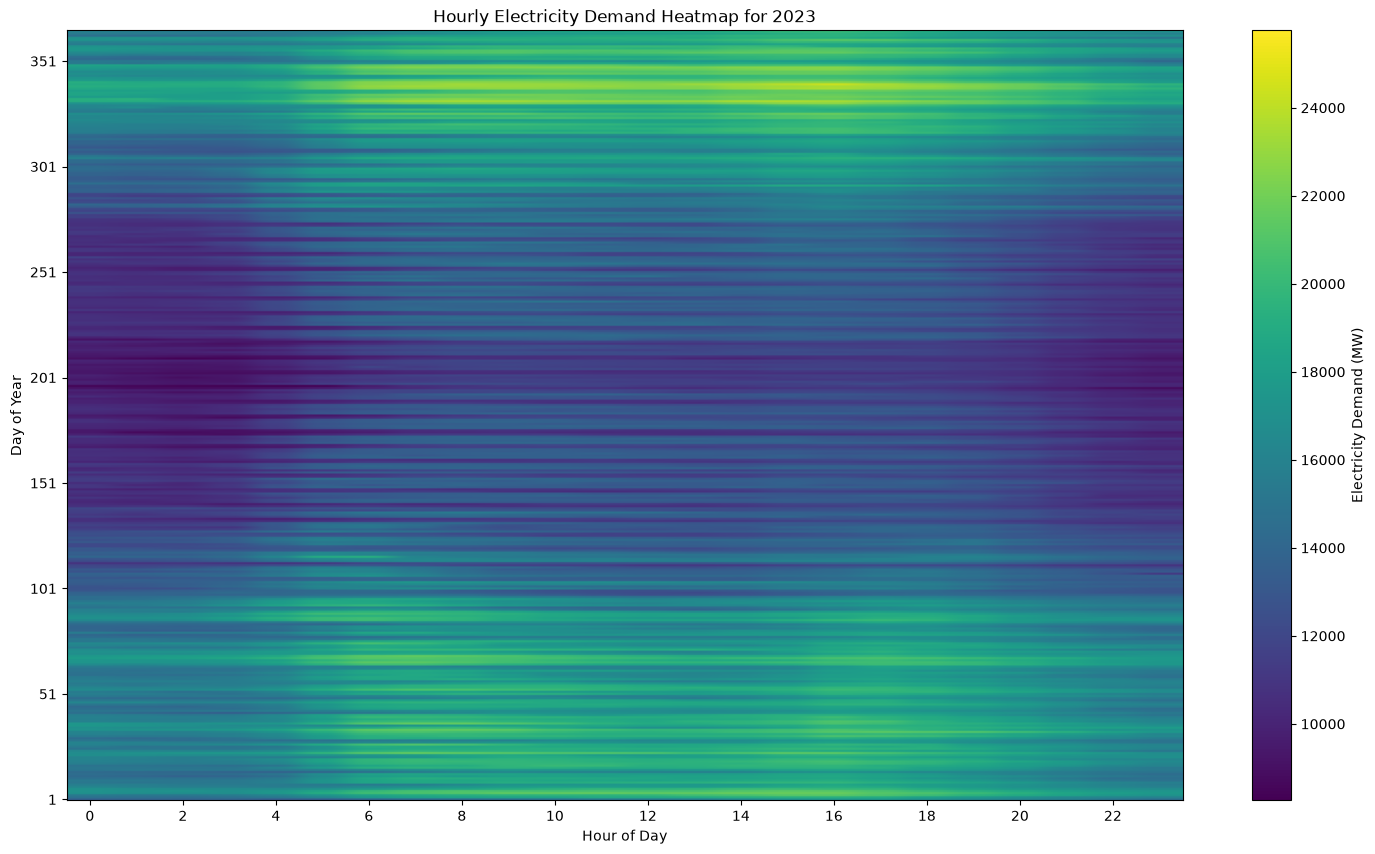

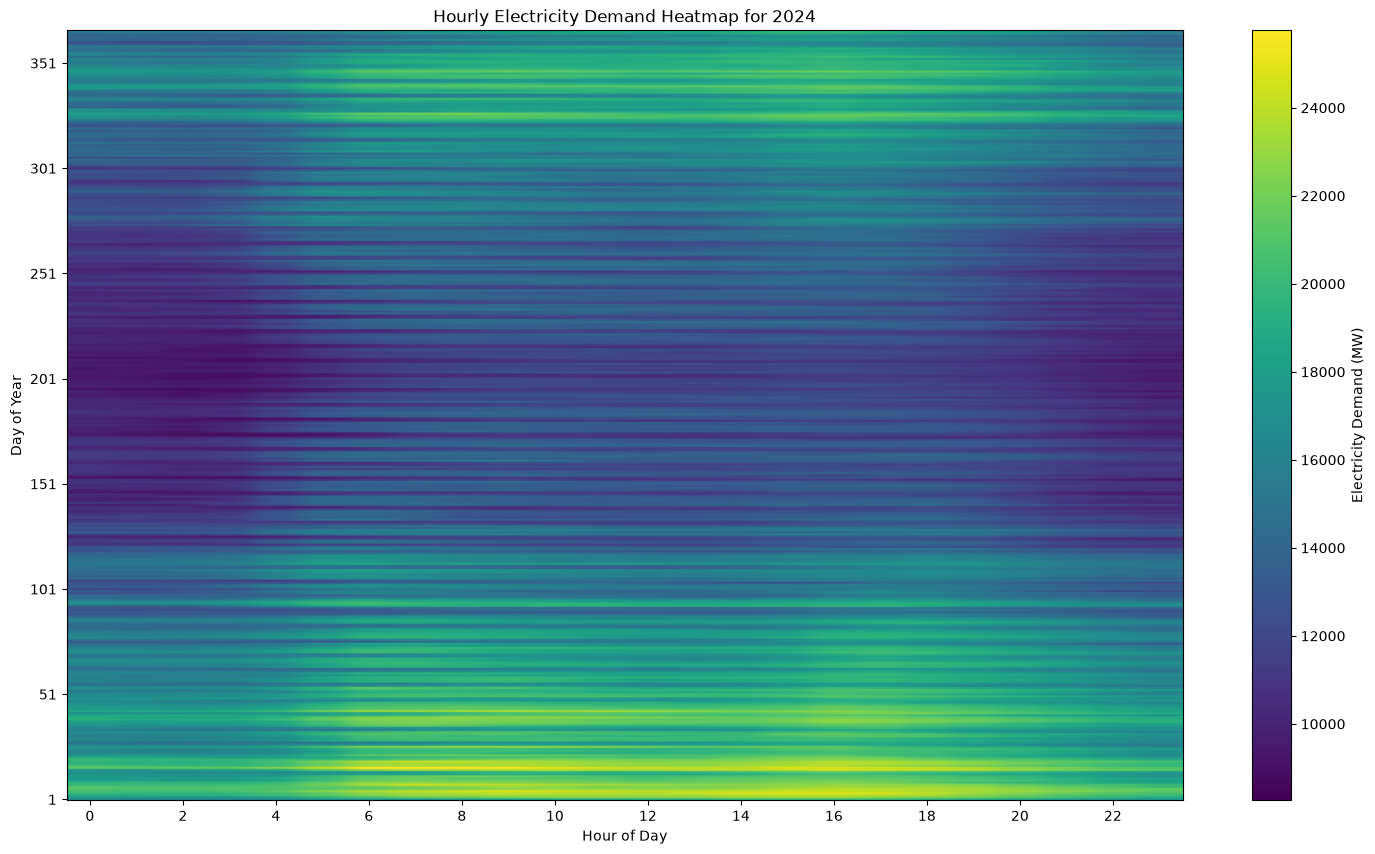

In [11]:
# Number of days in each year
years = {
    "2022": 365,
    "2023": 365,
    "2024": 366
}
heatmaps_data_by_year = {}#prepare all yearly slices and store them
start_day = 0
for year, num_days in years.items():
    end_day = start_day + num_days
    heatmaps_data_by_year[year] = demand2D[start_day:end_day, :]
    start_day = end_day

#  global vmin and vmax for consistent color scaling
all_demand_values = np.concatenate([v.flatten() for v in heatmaps_data_by_year.values()])
vmin = np.min(all_demand_values)
vmax = np.max(all_demand_values)

# Plotting heatmaps
for year, data in heatmaps_data_by_year.items():
    plt.figure(figsize=(18, 10))
    plt.imshow(data, cmap='viridis', aspect="auto", origin='lower', vmin=vmin, vmax=vmax)
    plt.title(f'Hourly Electricity Demand Heatmap for {year}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Year')
    plt.colorbar(label='Electricity Demand (MW)')
    plt.xticks(np.arange(0, 24, 2))
    plt.yticks(np.arange(0, data.shape[0], 50), np.arange(1, data.shape[0] + 1, 50))
    plt.show()


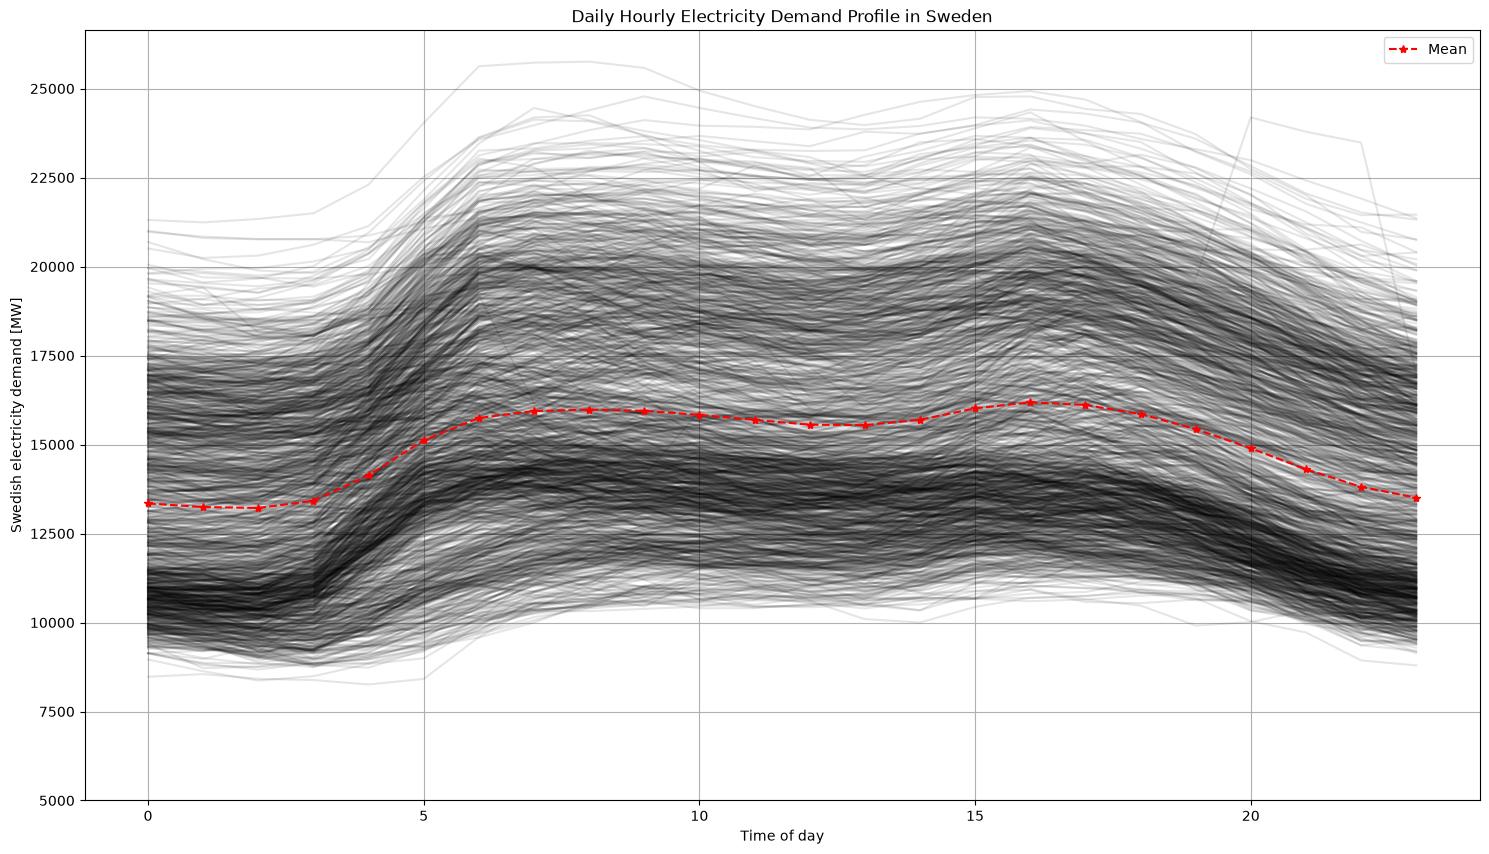

In [12]:
plt.figure(figsize=(18, 10))
plt.plot(demand2D.T, alpha=0.1, color='black')
plt.plot(np.nanmean(demand2D, axis=0), '*--', label="Mean", color="red")
plt.title('Daily Hourly Electricity Demand Profile in Sweden')
plt.xlabel('Time of day')
plt.ylabel('Swedish electricity demand [MW]')
plt.ylim(bottom=5000)  # Start y-axis from 5000
plt.grid(True)
plt.legend()
plt.show()


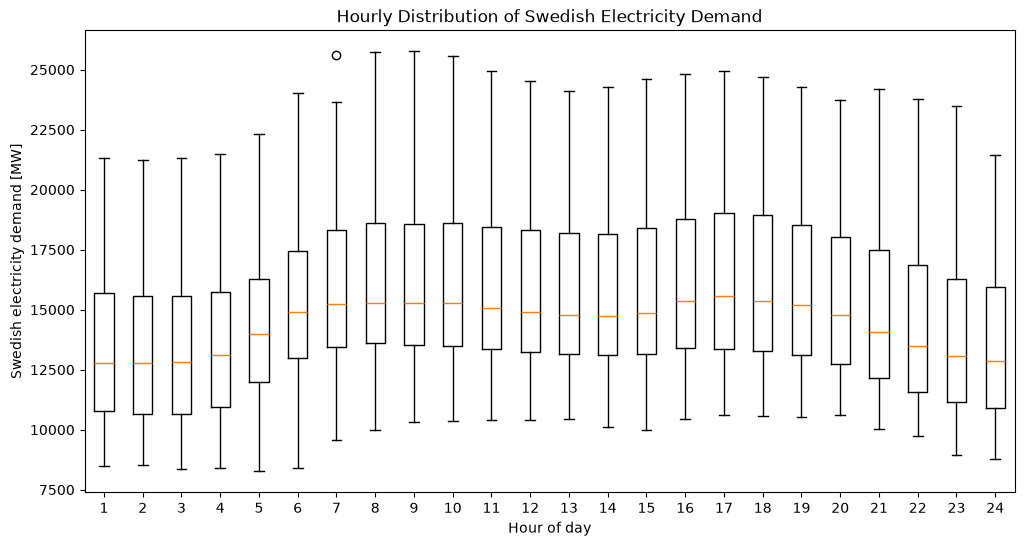

In [13]:
demand2D_3years = demand2D[:1096, :] #first 3 years from demand2D
plt.figure(figsize=(12, 6))
plt.boxplot(np.where(np.isnan(demand2D_3years), np.nanmean(demand2D_3years, axis=0), demand2D_3years))
plt.title('Hourly Distribution of Swedish Electricity Demand')
plt.xlabel('Hour of day')
plt.ylabel('Swedish electricity demand [MW]')
plt.grid(False)
plt.show()

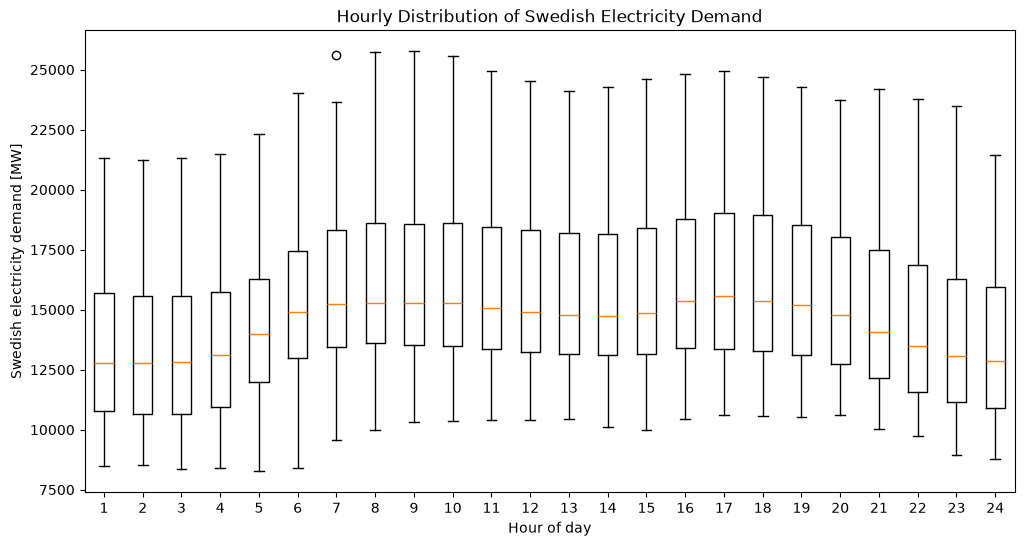

In [14]:
demand2D_3years = demand2D[:1096, :] #first 3 years from demand2D
plt.figure(figsize=(12, 6))
plt.boxplot(np.where(np.isnan(demand2D_3years), np.nanmean(demand2D_3years, axis=0), demand2D_3years))
plt.title('Hourly Distribution of Swedish Electricity Demand')
plt.xlabel('Hour of day')
plt.ylabel('Swedish electricity demand [MW]')
plt.grid(False)
plt.show()

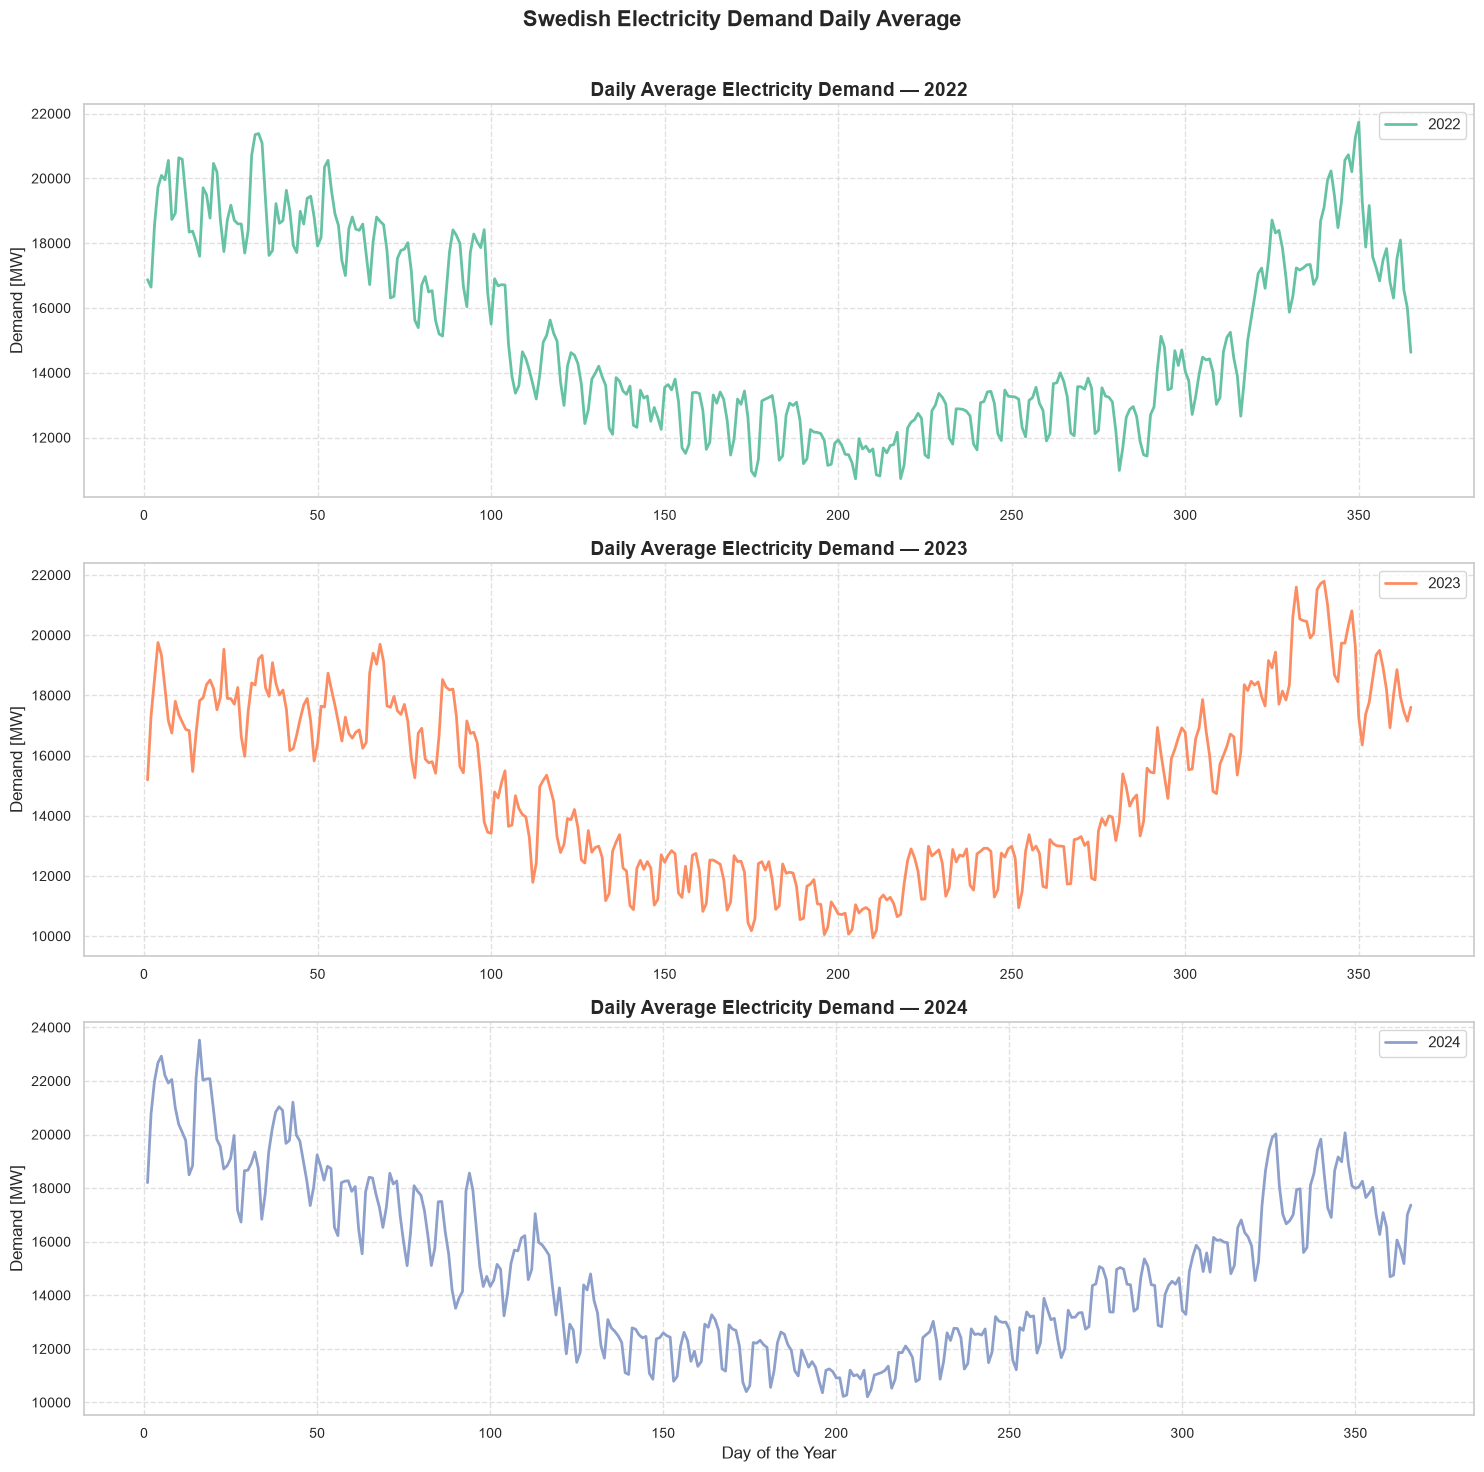

In [16]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

#colors
colors = sns.color_palette("Set2", 4)
year_keys = list(years.keys())

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 15), sharex=False)  

for i, year in enumerate(['2022', '2023', '2024']):
    num_days = years[year]
    start = sum([years[y] for y in year_keys if y < year])
    end = start + num_days
    year_data = demand2D[start:end, :]
    daily_mean = np.nanmean(year_data, axis=1)

    axes[i].plot(np.arange(1, num_days + 1), daily_mean, label=year, color=colors[i], linewidth=2)
    axes[i].set_title(f'Daily Average Electricity Demand — {year}', fontweight='bold')
    axes[i].set_ylabel('Demand [MW]')
    axes[i].legend(loc='upper right')
    axes[i].grid(visible=True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Day of the Year')
fig.suptitle("Swedish Electricity Demand Daily Average", fontsize=16, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

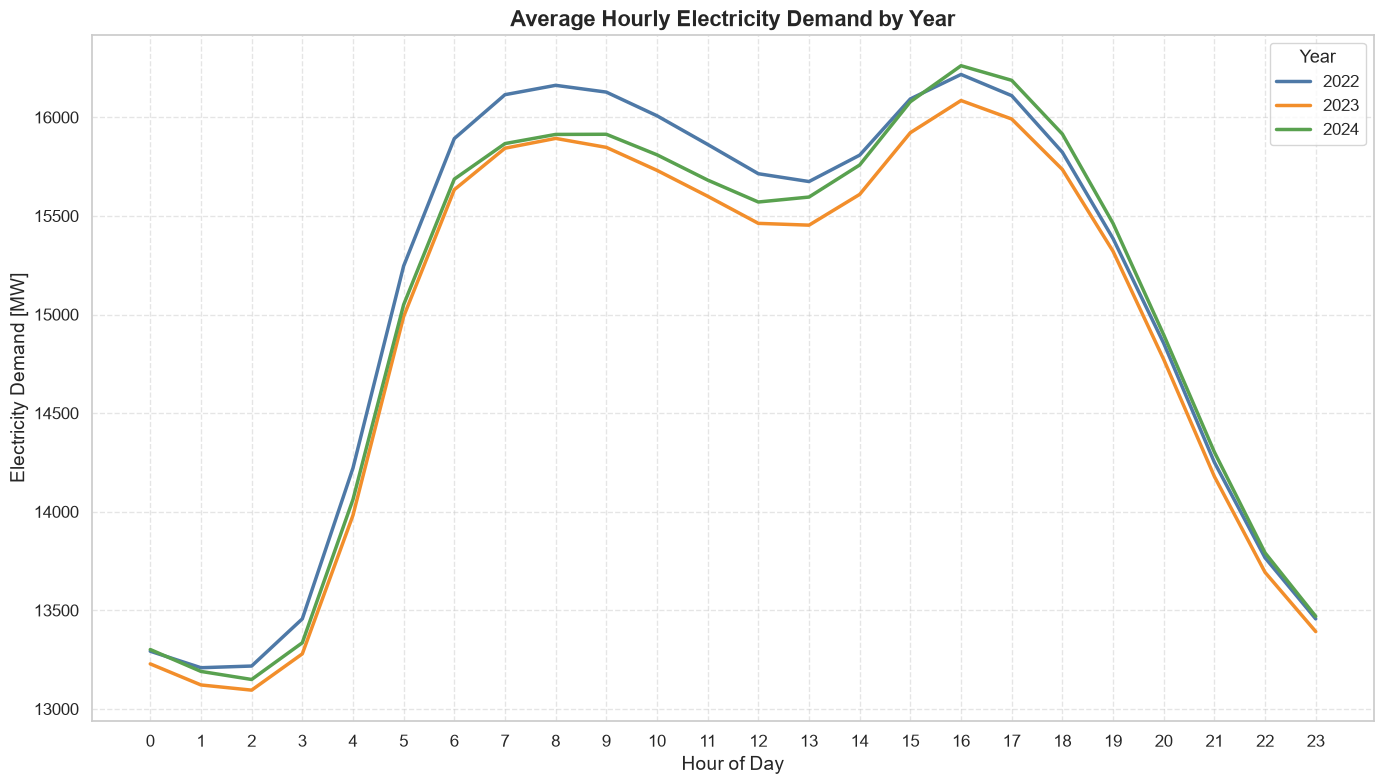

In [17]:
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']
plt.figure(figsize=(14, 8))

for i, (year, num_days) in enumerate(years.items()):
    start = sum(list(years.values())[:i])
    end = start + num_days
    year_data = demand2D[start:end, :]
    hourly_avg = np.nanmean(year_data, axis=0)
    plt.plot(hourly_avg, label=f"{year}", color=colors[i], linewidth=2.5)

plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Electricity Demand [MW]', fontsize=14)
plt.title('Average Hourly Electricity Demand by Year', fontsize=16, weight='bold')
plt.grid(True, linestyle='--',alpha=0.5)
plt.xticks(ticks=range(0, 24), labels=[f"{h}" for h in range(24)], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Year', fontsize=12, title_fontsize=13, loc='upper right')
plt.tight_layout()
plt.show()


A significant demand reduction in 2023 was primarily driven by high electricity prices from geopolitical factors, milder winter weather, and industrial cutbacks. By 2024, demand rebounded, with average evening peaks surpassing 2022 levels, while renewable generation (wind and solar) significantly expanded, leading to increased price volatility that might have influenced consumption patterns.

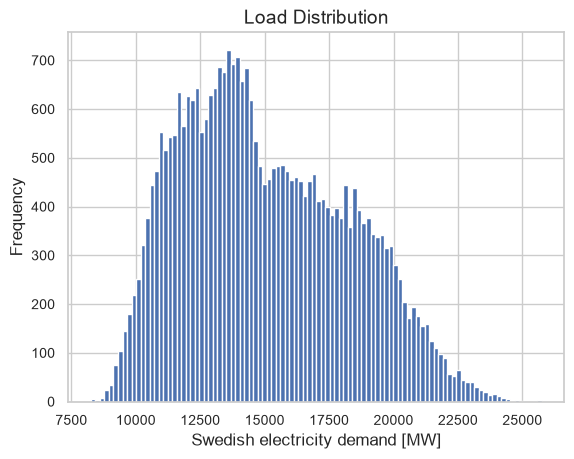

In [18]:
plt.hist(df.total_demand, bins=100)
plt.title('Load Distribution', fontsize=14,)
plt.xlabel('Swedish electricity demand [MW]')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

This histogram illustrates the distribution of Swedish electricity demand, revealing that the most frequently occurring demand levels are concentrated from 14,000 to 15,000 MW. The distribution is right-skewed, while average demand is moderate, higher demand values (up to 24,000-25,000 MW) occur less frequently, highlighting the impact of peak consumption periods.

## Filtering The Data

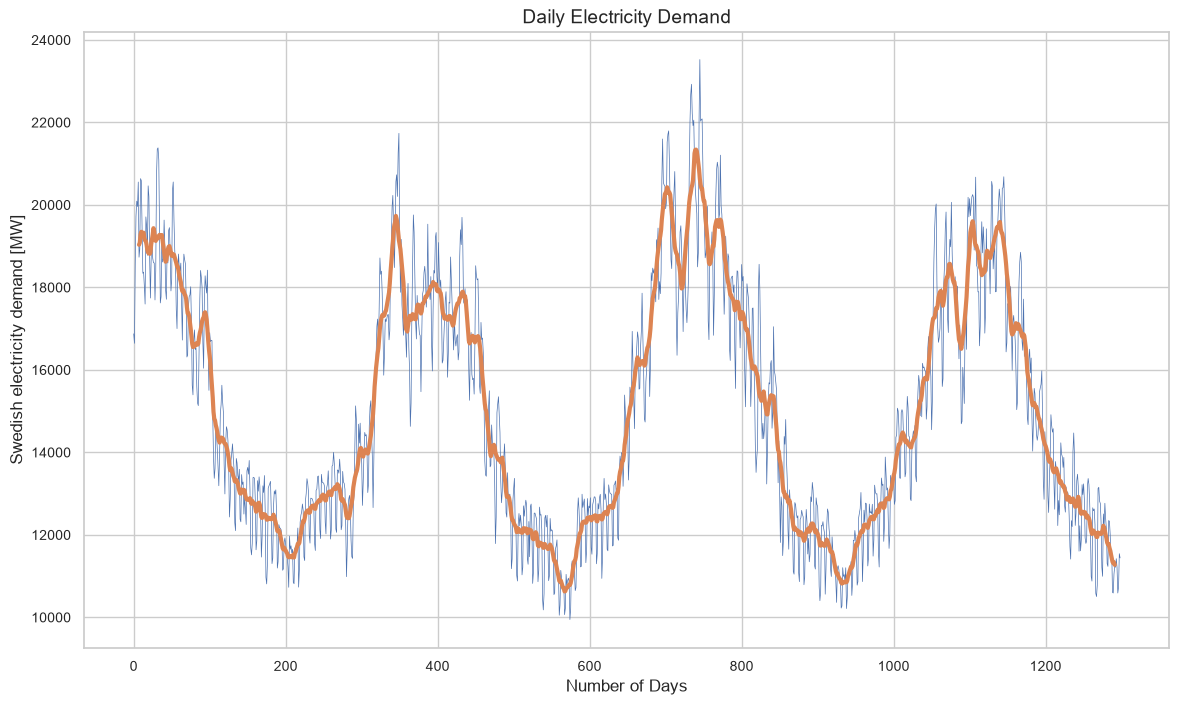

In [19]:
daily_average_demand = np.nanmean(demand2D, axis=1)
plt.figure(figsize=(14, 8))
plt.plot(daily_average_demand, linewidth=0.5)
plt.plot(pd.Series(daily_average_demand).rolling(15, center=True).mean(), linewidth=3)
plt.title('Daily Electricity Demand')
plt.xlabel('Number of Days')
plt.ylabel('Swedish electricity demand [MW]')

plt.grid(True)
plt.show()

This visualization uses a 15-day rolling average to highlight the dominant seasonal patterns in Swedish daily electricity demand. It clearly shows the consistent annual cycle of high demand in winter and low demand in summer, while the displaying the significant day-to-day variability around this predictable trend.

## Resampling The Data for 2024

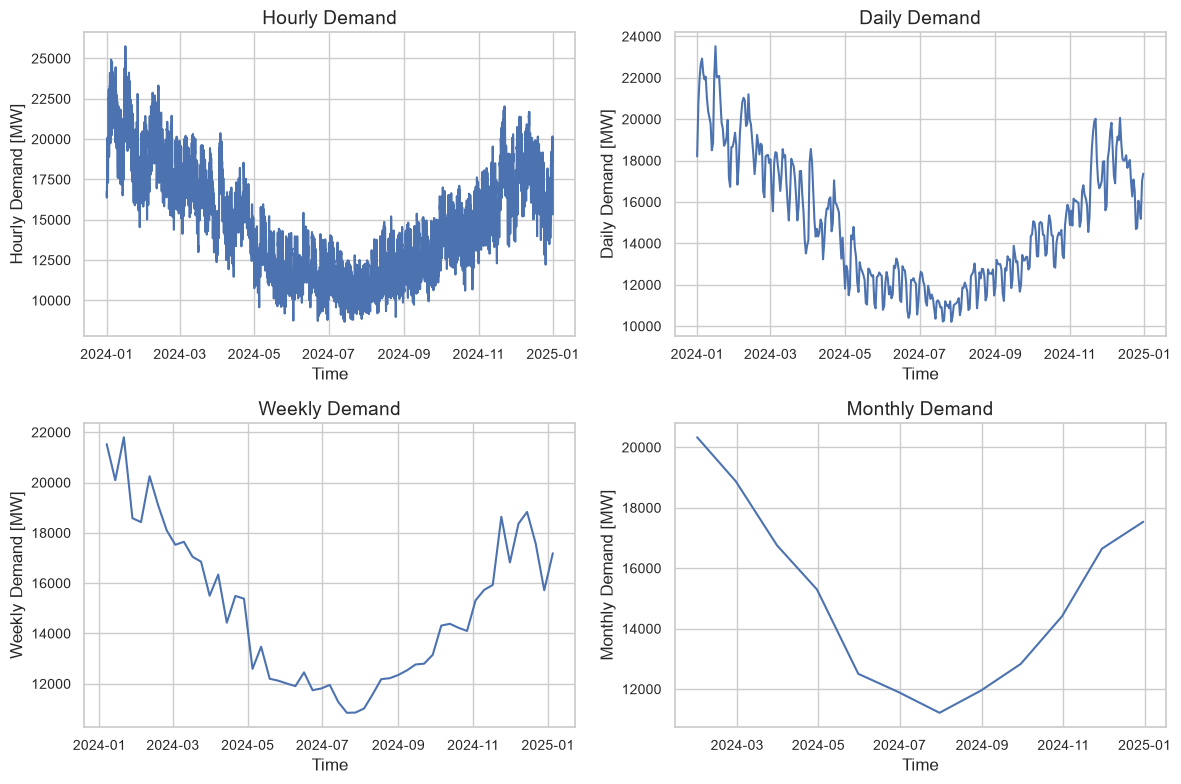

In [22]:
#Filter for 2024 
df_2024 = df[df.index.year == 2024]

#Resample for 2024
hourly_demand = df_2024.resample('1h').mean(numeric_only=True)
daily_demand = df_2024.resample('1D').mean(numeric_only=True)
weekly_demand = df_2024.resample('1W').mean(numeric_only=True)
monthly_demand = df_2024.resample('1ME').mean(numeric_only=True)

#Plotting
fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(hourly_demand.index, hourly_demand['total_demand'])
plt.xlabel('Time')
plt.ylabel('Hourly Demand [MW]')
plt.title('Hourly Demand')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(daily_demand.index, daily_demand['total_demand'])
plt.xlabel('Time')
plt.ylabel('Daily Demand [MW]')
plt.title('Daily Demand')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(weekly_demand.index, weekly_demand['total_demand'])
plt.xlabel('Time')
plt.ylabel('Weekly Demand [MW]')
plt.title('Weekly Demand')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(monthly_demand.index, monthly_demand['total_demand'])
plt.xlabel('Time')
plt.ylabel('Monthly Demand [MW]')
plt.title('Monthly Demand')
plt.grid(True)

plt.tight_layout()
plt.show()


This set of visualizations illustrates Swedish electricity demand at hourly, daily, weekly, and monthly aggregations for 2024. They reveal  that strong annual seasonality (high in winter, and low in summer) is the dominant and highly predictable characteristic of Swedish electricity demand across all resolutions.